### Dataset

In [4]:
import os
from tqdm import tqdm

def count_trains(split_dir):
    labels_dir = os.path.join(split_dir, "labels")

    images_with_trains = 0
    images_without_trains = 0
    images_with_multiple_trains=0
    total_boxes = 0

    for label_file in tqdm(os.listdir(labels_dir), desc=f"Processing {split_dir}"):
        if not label_file.endswith(".txt"):
            continue

        label_path = os.path.join(labels_dir, label_file)

        with open(label_path, "r") as f:
            lines = [line.strip() for line in f if line.strip()]

        if len(lines) > 0:
            images_with_trains += 1
            total_boxes += len(lines)
            if len(lines) > 1:
                images_with_multiple_trains+=1
        else:
            images_without_trains += 1

    total_images = images_with_trains + images_without_trains

    return {
        "total_images": total_images,
        "images_with_trains": images_with_trains,
        "images_with_multiple_trains": images_with_multiple_trains,
        "images_without_trains": images_without_trains,
        "total_train_instances": total_boxes
    }


# Root directory of your dataset
dataset_root = "/data22/datasets/zollner_dataset/paper_data/"

for split in ["train", "val", "test"]:
    split_path = os.path.join(dataset_root, split)
    stats = count_trains(split_path)

    print(f"\n📁 {split.upper()} SET")
    for k, v in stats.items():
        print(f"{k}: {v}")

Processing /data22/datasets/zollner_dataset/paper_data/train:   0%|          | 0/5600 [00:00<?, ?it/s]

Processing /data22/datasets/zollner_dataset/paper_data/train: 100%|██████████| 5600/5600 [00:00<00:00, 6602.71it/s]



📁 TRAIN SET
total_images: 5600
images_with_trains: 4519
images_with_multiple_trains: 18
images_without_trains: 1081
total_train_instances: 4537


Processing /data22/datasets/zollner_dataset/paper_data/val: 100%|██████████| 700/700 [00:00<00:00, 6484.13it/s]



📁 VAL SET
total_images: 700
images_with_trains: 569
images_with_multiple_trains: 2
images_without_trains: 131
total_train_instances: 571


Processing /data22/datasets/zollner_dataset/paper_data/test: 100%|██████████| 700/700 [00:00<00:00, 34799.66it/s]


📁 TEST SET
total_images: 700
images_with_trains: 563
images_with_multiple_trains: 4
images_without_trains: 137
total_train_instances: 567


In [10]:
# import cv2
# import os
# import numpy as np
# from collections import Counter

# def classify_time_of_day(image_path):
#     img = cv2.imread(image_path)
#     if img is None:
#         return "unknown"

#     # Resize for speed
#     img = cv2.resize(img, (256, 256))

#     # ----- Brightness (HSV) -----
#     hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
#     brightness = np.mean(hsv[:, :, 2])

#     # ----- Color warmth (BGR) -----
#     b, g, r = cv2.split(img)
#     warmth = np.mean(r) - np.mean(b)

#     # ----- Heuristic thresholds -----
#     if brightness < 50:
#         return "night"
#     elif brightness < 120:
#         return "evening"
#     else:
#         if warmth > 15:
#             return "evening"
#         else:
#             return "day"


# def analyze_split(split_dir):
#     images_dir = os.path.join(split_dir, "images")
#     counts = Counter()

#     for img_file in os.listdir(images_dir):
#         if not img_file.lower().endswith((".jpg", ".png", ".jpeg")):
#             continue

#         img_path = os.path.join(images_dir, img_file)
#         tod = classify_time_of_day(img_path)
#         counts[tod] += 1

#     return counts


# dataset_root = "/data22/datasets/zollner_dataset/paper_data/"

# for split in ["train", "val", "test"]:
#     split_path = os.path.join(dataset_root, split)
#     stats = analyze_split(split_path)

#     print(f"\n📁 {split.upper()} SET")
#     for k, v in stats.items():
#         print(f"{k}: {v}")



📁 TRAIN SET
evening: 1562
day: 2157
night: 1881

📁 VAL SET
night: 211
day: 292
evening: 197

📁 TEST SET
day: 274
evening: 182
night: 244


In [5]:
import cv2
import os
import random
import shutil
import numpy as np
from collections import defaultdict
from tqdm import tqdm

def classify_day_night_old(image_path, threshold=80):
    img = cv2.imread(image_path)
    if img is None:
        return "unknown"

    img = cv2.resize(img, (256, 256))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    brightness = np.mean(hsv[:, :, 2])

    return "night" if brightness < threshold else "day"


def classify_day_night(image_path, threshold=60):
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image: {image_path}")

    height, width = img.shape[:2]

    # Define ROI: top-right corner (adjust size if needed)
    roi = img[0:int(0.25*height), int(0.75*width):width]  # top 25% height, right 25% width

    # Convert ROI to grayscale
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    # Compute average brightness
    avg_brightness = np.mean(gray)

    # Decide day/night
    if avg_brightness > threshold:
        return "Day"
    else:
        return "Night"


def classify_day_night_roi(image_path, threshold=60):
    img = cv2.imread(image_path)
    if img is None:
        return "unknown"

    h, w, _ = img.shape

    # ---- Crop top-right corner (sky region) ----
    roi = img[0:int(0.25 * h), int(0.65 * w):w]

    # Convert to HSV
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    brightness = np.mean(hsv[:, :, 2])

    return "night" if brightness < threshold else "day"


dataset_root = "/data22/datasets/zollner_dataset/paper_data/"
output_root = "manual_check_day_night"
os.makedirs(output_root, exist_ok=True)

images_by_class = defaultdict(list)

# Collect predictions
for split in ["train", "val", "test"]:
    images_dir = os.path.join(dataset_root, split, "images")
    for img_file in tqdm(os.listdir(images_dir)):
        if img_file.lower().endswith((".jpg", ".png", ".jpeg")):
            img_path = os.path.join(images_dir, img_file)
            pred = classify_day_night_roi(img_path)
            if pred in ["day", "night"]:
                images_by_class[pred].append(img_path)

# Sample & copy
SAMPLES_PER_CLASS = 50

for cls in ["day", "night"]:
    os.makedirs(os.path.join(dataset_root,output_root, cls), exist_ok=True)

    for img_path in tqdm(images_by_class[cls]):
        #make label file of type txt and add day or night to it accordingly
        label_path = os.path.join(dataset_root,output_root, cls, os.path.basename(img_path).replace(".jpg", ".txt").replace(".png", ".txt"))
        # print(f"Creating label file: {label_path}")
        with open(label_path, "w") as f:
            f.write(cls)        

100%|██████████| 3688/3688 [00:00<00:00, 16719.78it/s]


In [6]:
print(f"Day time images: {len(images_by_class['day'])}- {100*len(images_by_class['day'])/7000} \nNight time images: {len(images_by_class['night'])} - {100*len(images_by_class['night'])/7000}")

Day time images: 3312- 47.31428571428572 
Night time images: 3688 - 52.68571428571428


In [ ]:
# from pathlib import Path
# from collections import defaultdict

# def bbox_size_distribution(
#     labels_dir,
#     small_thr=0.1,
#     large_thr=0.5
# ):
#     """
#     Compute percentage distribution of bbox sizes from YOLO labels.

#     Args:
#         labels_dir (str or Path): path to folder containing .txt label files
#         small_thr (float): area threshold for small boxes
#         large_thr (float): area threshold for large boxes

#     Returns:
#         dict with counts and percentages
#     """
#     labels_dir = Path(labels_dir)

#     counts = defaultdict(int)
#     total_boxes = 0

#     for label_file in labels_dir.glob("*.txt"):
#         with open(label_file) as f:
#             for line in f:
#                 parts = line.strip().split()
#                 if len(parts) < 5:
#                     continue

#                 try:
#                     w = float(parts[3])
#                     h = float(parts[4])
#                 except ValueError:
#                     continue

#                 area = w * h
#                 total_boxes += 1

#                 if area < small_thr:
#                     counts["small"] += 1
#                 elif area < large_thr:
#                     counts["medium"] += 1
#                 else:
#                     counts["large"] += 1

#     percentages = {
#         k: (v / max(total_boxes, 1)) * 100
#         for k, v in counts.items()
#     }

#     return {
#         "total_boxes": total_boxes,
#         "counts": dict(counts),
#         "percentages": percentages,
#     }


In [41]:
stats = bbox_size_distribution("/data22/datasets/zollner_dataset/paper_data/labels")

print("Total boxes:", stats["total_boxes"])
print("Counts:", stats["counts"])
print("Percentages:", stats["percentages"])


Total boxes: 5676
Counts: {'large': 2305, 'medium': 1840, 'small': 1531}
Percentages: {'large': 40.609584214235376, 'medium': 32.41719520789289, 'small': 26.973220577871743}


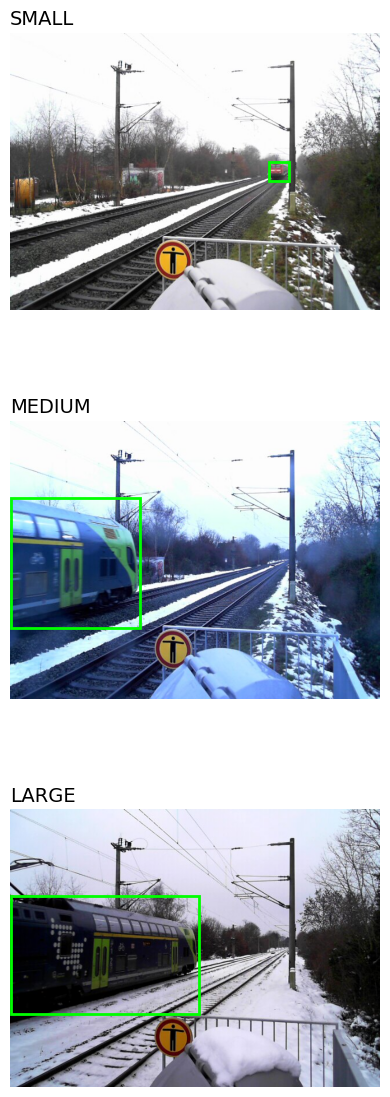

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches
# import numpy as np
# from tqdm import tqdm
# from pathlib import Path
# import random
# import matplotlib.image as mpimg

# def draw_yolo_boxes_matplotlib(ax, img, labels, color="lime"):
#     h, w = img.shape[:2]

#     ax.imshow(img)
#     ax.axis("off")

#     for cls, xc, yc, bw, bh in labels:
#         x = (xc - bw / 2) * w
#         y = (yc - bh / 2) * h
#         bw *= w
#         bh *= h

#         rect = patches.Rectangle(
#             (x, y),
#             bw,
#             bh,
#             linewidth=2,
#             edgecolor=color,
#             facecolor="none",
#         )
#         ax.add_patch(rect)




# def collect_bbox_size_samples(
#     images_dir,
#     labels_dir,
#     samples_per_category=4,
#     small_thr=0.2, # 20% width/height threshold
#     large_thr=0.5, # 50% width/height threshold
# ):
#     images_dir = Path(images_dir)
#     labels_dir = Path(labels_dir)

#     buckets = {"small": [], "medium": [], "large": []}

#     image_files = list(images_dir.glob("*.*"))
#     random.shuffle(image_files)

#     for img_path in tqdm(image_files, desc="Collecting bbox size samples"):
#         label_path = labels_dir / f"{img_path.stem}.txt"
#         if not label_path.exists():
#             continue

#         labels = []
#         categories = set()

#         with open(label_path) as f:
#             for line in f:
#                 cls, xc, yc, bw, bh = map(float, line.split())
#                 labels.append((cls, xc, yc, bw, bh))

#                 area = bw * bh
#                 side = max(bw, bh)  # largest relative dimension

#                 # ---- New rule: consider area AND width/height ----
#                 if area < small_thr and bw < small_thr and bh < small_thr:
#                     categories.add("small")
#                 elif area >= large_thr or side >= large_thr:
#                     categories.add("large")
#                 else:
#                     categories.add("medium")

#         for cat in categories:
#             if len(buckets[cat]) < samples_per_category:
#                 img = mpimg.imread(img_path)
#                 buckets[cat].append((img, labels))

#         if all(len(v) >= samples_per_category for v in buckets.values()):
#             break

#     return buckets


# def plot_bbox_samples(samples):
#     categories = ["small", "medium", "large"]
#     n_rows = len(categories)
#     n_cols = max(len(samples[c]) for c in categories)

#     fig, axes = plt.subplots(
#         n_rows,
#         n_cols,
#         figsize=(4 * n_cols, 4 * n_rows),
#         squeeze=False,
#     )

#     for row, cat in enumerate(categories):
#         for col in range(n_cols):
#             ax = axes[row][col]
#             ax.axis("off")

#             if col >= len(samples[cat]):
#                 continue

#             img, labels = samples[cat][col]
#             draw_yolo_boxes_matplotlib(ax, img, labels)

#             if col == 0:
#                 ax.set_title(cat.upper(), fontsize=14, loc="left")

#     plt.tight_layout()
#     plt.show()


# samples = collect_bbox_size_samples(
#     images_dir="/data22/datasets/zollner_dataset/paper_data/images",
#     labels_dir="/data22/datasets/zollner_dataset/paper_data/labels",
#     samples_per_category=1,
# )

# plot_bbox_samples(samples)


In [4]:
len(samples['small'])

0

### BBOX size distrubution and saved images accordingly

In [15]:
import shutil
from pathlib import Path
from typing import Tuple, List, Optional

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def yolo_labels_dir_from_images_dir(images_dir: Path) -> Path:
    """
    Typical YOLO layout:
      .../images/<split>/xxx.jpg  -> .../labels/<split>/xxx.txt
      .../images/xxx.jpg          -> .../labels/xxx.txt
    This function replaces '/images' with '/labels' in the path (first occurrence).
    """
    s = str(images_dir)
    if "/images" in s:
        return Path(s.replace("/images", "/labels", 1))
    # fallback: sibling labels directory
    return images_dir.parent / "labels"


def parse_yolo_label_file(label_path: Path) -> List[Tuple[int, float, float, float, float]]:
    """
    Each line: cls xc yc w h  (normalized)
    Returns list of tuples.
    """
    rows = []
    txt = label_path.read_text().strip()
    if not txt:
        return rows
    for line in txt.splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls = int(float(parts[0]))
        xc, yc, w, h = map(float, parts[1:5])
        rows.append((cls, xc, yc, w, h))
    return rows


def image_bucket_for_file(
    label_path: Path,
    small_thr: float = 0.10,
    large_thr: float = 0.50,
    mode: str = "max_side",
) -> Optional[str]:
    """
    Decide bucket for an IMAGE based on its boxes.

    mode:
      - "max_side": uses max(w, h) over all boxes in the image
      - "any_box": assigns to the largest bucket present (e.g., if any box is large -> large)
    """
    boxes = parse_yolo_label_file(label_path)
    if not boxes:
        return None  # background/unlabeled/empty label file

    # compute per-box max side
    max_sides = [max(w, h) for (_, _, _, w, h) in boxes]

    if mode == "max_side":
        m = max(max_sides)  # largest object in image decides
        if m < small_thr:
            return "small"
        elif m <= large_thr:
            return "medium"
        else:
            return "large"

    elif mode == "any_box":
        # If any large -> large, else if any medium -> medium, else small
        if any(ms > large_thr for ms in max_sides):
            return "large"
        if any((ms >= small_thr) and (ms <= large_thr) for ms in max_sides):
            return "medium"
        return "small"

    else:
        raise ValueError(f"Unknown mode: {mode}")


def copy_pair(img_path: Path, label_path: Path, out_images: Path, out_labels: Path):
    out_images.mkdir(parents=True, exist_ok=True)
    out_labels.mkdir(parents=True, exist_ok=True)

    shutil.copy2(img_path, out_images / img_path.name)
    shutil.copy2(label_path, out_labels / label_path.name)


def main(
    images_dir: str,
    out_root: str,
    small_thr: float = 0.10,
    large_thr: float = 0.50,
    include_background: bool = False,
    mode: str = "max_side",
):
    images_dir = Path(images_dir)
    labels_dir = yolo_labels_dir_from_images_dir(images_dir)

    if not images_dir.exists():
        raise FileNotFoundError(f"Images dir not found: {images_dir}")
    if not labels_dir.exists():
        print(f"[WARN] Labels dir not found: {labels_dir} (will treat all as background)")
    
    out_root = Path(out_root)
    # Output structure:
    # out_root/
    #   small/images, small/labels
    #   medium/images, medium/labels
    #   large/images, large/labels
    #   background/images, background/labels (optional)
    buckets = ["small", "medium", "large"] + (["background"] if include_background else [])

    counts = {b: 0 for b in buckets}
    missing_labels = 0

    img_files = [p for p in images_dir.iterdir() if p.suffix.lower() in IMG_EXTS and p.is_file()]
    print(f"[INFO] Found {len(img_files)} images in {images_dir}")
    print(f"[INFO] Labels dir: {labels_dir}")
    print(f"[INFO] Buckets: small < {small_thr}, medium {small_thr}..{large_thr}, large > {large_thr}")
    print(f"[INFO] Decision mode: {mode}")

    for img_path in tqdm(img_files, desc="Processing images"):
        label_path = labels_dir / f"{img_path.stem}.txt"

        if not label_path.exists():
            missing_labels += 1
            if include_background:
                # create empty label in output (optional)
                out_img_dir = out_root / "background" / "images"
                out_lbl_dir = out_root / "background" / "labels"
                out_img_dir.mkdir(parents=True, exist_ok=True)
                out_lbl_dir.mkdir(parents=True, exist_ok=True)

                shutil.copy2(img_path, out_img_dir / img_path.name)
                (out_lbl_dir / f"{img_path.stem}.txt").write_text("")
                counts["background"] += 1
            continue

        bucket = image_bucket_for_file(label_path, small_thr=small_thr, large_thr=large_thr, mode=mode)
        if bucket is None:
            # label exists but empty -> background
            if include_background:
                out_img_dir = out_root / "background" / "images"
                out_lbl_dir = out_root / "background" / "labels"
                out_img_dir.mkdir(parents=True, exist_ok=True)
                out_lbl_dir.mkdir(parents=True, exist_ok=True)

                shutil.copy2(img_path, out_img_dir / img_path.name)
                shutil.copy2(label_path, out_lbl_dir / label_path.name)
                counts["background"] += 1
            continue

        out_img_dir = out_root / bucket / "images"
        out_lbl_dir = out_root / bucket / "labels"
        copy_pair(img_path, label_path, out_img_dir, out_lbl_dir)
        counts[bucket] += 1

    print("\n=== DONE ===")
    for b in buckets:
        print(f"{b:>10}: {counts[b]}")
    print(f"missing_labels: {missing_labels}")
    print(f"Output root: {out_root}")


if __name__ == "__main__":
    # --------- EDIT THESE ----------
    IMAGES_DIR="/data22/datasets/zollner_dataset/paper_data/images"
    OUT_ROOT="/data22/datasets/zollner_dataset/paper_data/bbox_size_buckets"
    # IMAGES_DIR = "/path/to/your/images"     # e.g. /data22/datasets/zollner_dataset/paper_data/test/images
    # OUT_ROOT   = "/path/to/output_buckets"  # e.g. /data22/datasets/zollner_dataset/bbox_size_buckets_test
    # -------------------------------

    main(
        images_dir=IMAGES_DIR,
        out_root=OUT_ROOT,
        small_thr=0.15,
        large_thr=0.60,
        include_background=True,   # set True if you also want background bucket copied
        mode="any_box",            # "max_side" is usually what you want
    )


[INFO] Found 7000 images in /data22/datasets/zollner_dataset/paper_data/images
[INFO] Labels dir: /data22/datasets/zollner_dataset/paper_data/labels
[INFO] Buckets: small < 0.15, medium 0.15..0.6, large > 0.6
[INFO] Decision mode: any_box


Processing images: 100%|██████████| 7000/7000 [00:02<00:00, 2712.99it/s]


=== DONE ===
     small: 984
    medium: 1110
     large: 3558
background: 1348
missing_labels: 0
Output root: /data22/datasets/zollner_dataset/paper_data/bbox_size_buckets


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
from pathlib import Path
import random
import matplotlib.image as mpimg


def draw_yolo_boxes_matplotlib(ax, img, labels, color="lime"):
    h, w = img.shape[:2]
    ax.imshow(img)
    ax.axis("off")

    for cls, xc, yc, bw, bh in labels:
        x = (xc - bw / 2) * w
        y = (yc - bh / 2) * h
        bw_px = bw * w
        bh_px = bh * h

        rect = patches.Rectangle(
            (x, y),
            bw_px,
            bh_px,
            linewidth=2,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)


def collect_bbox_size_samples(
    images_dir,
    labels_dir,
    samples_per_category=4,
    small_thr=0.2,   # 20% width/height threshold
    large_thr=0.5,   # 50% width/height threshold
):
    images_dir = Path(images_dir)
    labels_dir = Path(labels_dir)

    buckets = {"small": [], "medium": [], "large": []}

    image_files = [p for p in images_dir.glob("*.*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    random.shuffle(image_files)

    for img_path in tqdm(image_files, desc="Collecting bbox size samples"):
        label_path = labels_dir / f"{img_path.stem}.txt"
        if not label_path.exists():
            continue

        labels = []
        categories = set()

        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue

                cls, xc, yc, bw, bh = map(float, parts[:5])
                labels.append((cls, xc, yc, bw, bh))

                area = bw * bh
                side = max(bw, bh)

                # small: area AND both sides below small_thr
                if area < small_thr and bw < small_thr and bh < small_thr:
                    categories.add("small")
                # large: area OR largest side above/equal large_thr
                elif area >= large_thr or side >= large_thr:
                    categories.add("large")
                else:
                    categories.add("medium")

        # store the SAME image under any category it contains
        for cat in categories:
            if len(buckets[cat]) < samples_per_category:
                img = mpimg.imread(img_path)
                buckets[cat].append((img_path, img, labels))  # include path for saving/logging

        if all(len(v) >= samples_per_category for v in buckets.values()):
            break

    return buckets


def plot_bbox_samples_individual(samples, save_dir=None, dpi=150):
    """
    Plots each sample as its own figure. Optionally saves each figure into save_dir.
    """
    save_dir = Path(save_dir) if save_dir else None
    if save_dir:
        save_dir.mkdir(parents=True, exist_ok=True)

    for cat, items in samples.items():
        for i, (img_path, img, labels) in enumerate(items):
            fig, ax = plt.subplots(figsize=(6, 6))
            draw_yolo_boxes_matplotlib(ax, img, labels)

            if save_dir:
                out_path = save_dir / f"{cat}_{i}_{img_path.stem}.pdf"
                plt.savefig(out_path, 
                            bbox_inches="tight",
                            pad_inches=0,          # ✅ removes the border/padding
                            transparent=True,       # ✅ optional (prevents white canvas edge)
                            dpi=dpi, 
                            format='pdf')
                plt.close(fig)
            else:
                plt.show()


# -------------------- RUN --------------------
samples = collect_bbox_size_samples(
    images_dir="/data22/datasets/zollner_dataset/paper_data/images",
    labels_dir="/data22/datasets/zollner_dataset/paper_data/labels",
    samples_per_category=1,
    small_thr=0.2,
    large_thr=0.5,
)

# Show one-by-one (no grid)
plot_bbox_samples_individual(samples, save_dir="/home/mal/ultralytics/rail_road_scripts/bbox_distribution_samples/")

# Or save them:
# plot_bbox_samples_individual(samples, save_dir="bbox_size_examples")


### Blurr or sharp distribution

In [1]:
import cv2
import os
from pathlib import Path

def is_blurry(image_path, threshold=100.0):
    """
    Returns (is_blurry, variance)
    """
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return True, 0.0  # treat unreadable images as blurry

    lap_var = cv2.Laplacian(img, cv2.CV_64F).var()
    return lap_var < threshold, lap_var


def find_blurry_images(images_dir, threshold=100.0):
    images_dir = Path(images_dir)

    blurry = []
    sharp = []

    for img_path in images_dir.glob("*.*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        blur, score = is_blurry(img_path, threshold)

        if blur:
            blurry.append((img_path, score))
        else:
            sharp.append((img_path, score))

    return blurry, sharp


In [12]:
images_dir = "/data22/datasets/zollner_dataset/paper_data/images"

blurry, sharp = find_blurry_images(images_dir, threshold=450)

print(f"Total images : {len(blurry) + len(sharp)}")
print(f"Blurry images: {len(blurry)}")
print(f"Sharp images : {len(sharp)}")

# Print some examples
for p, v in blurry[:10]:
    print(f"BLURRY | {p.name} | score={v:.2f}")


Total images : 7000
Blurry images: 3264
Sharp images : 3736
BLURRY | train_2023-12-10_04.35.46_053.jpg | score=361.85
BLURRY | train_2023-12-10_01.56.20_018.jpg | score=277.41
BLURRY | train_2023-12-09_05.55.05_055.jpg | score=371.55
BLURRY | train_2023-12-10_19.32.19_443.jpg | score=152.03
BLURRY | train_2023-12-10_03.56.24_560.jpg | score=206.85
BLURRY | train_2023-12-10_20.02.28_375.jpg | score=207.40
BLURRY | train_2023-12-10_05.12.18_556.jpg | score=404.03
BLURRY | train_2023-12-10_10.19.32_502.jpg | score=446.10
BLURRY | train_2023-12-10_21.52.19_665.jpg | score=404.73
BLURRY | train_2023-12-10_10.19.30_454.jpg | score=415.73


In [9]:
import matplotlib.pyplot as plt
import cv2

def show_images(image_tuples, title, max_images=12, cols=4):
    """
    image_tuples: list of (Path, score)
    """
    n = min(len(image_tuples), max_images)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten()

    for ax, (img_path, score) in zip(axes, image_tuples[:n]):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax.imshow(img)
        ax.set_title(f"{img_path.name}\nBlur={score:.1f}", fontsize=9)
        ax.axis("off")

    # Hide unused axes
    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


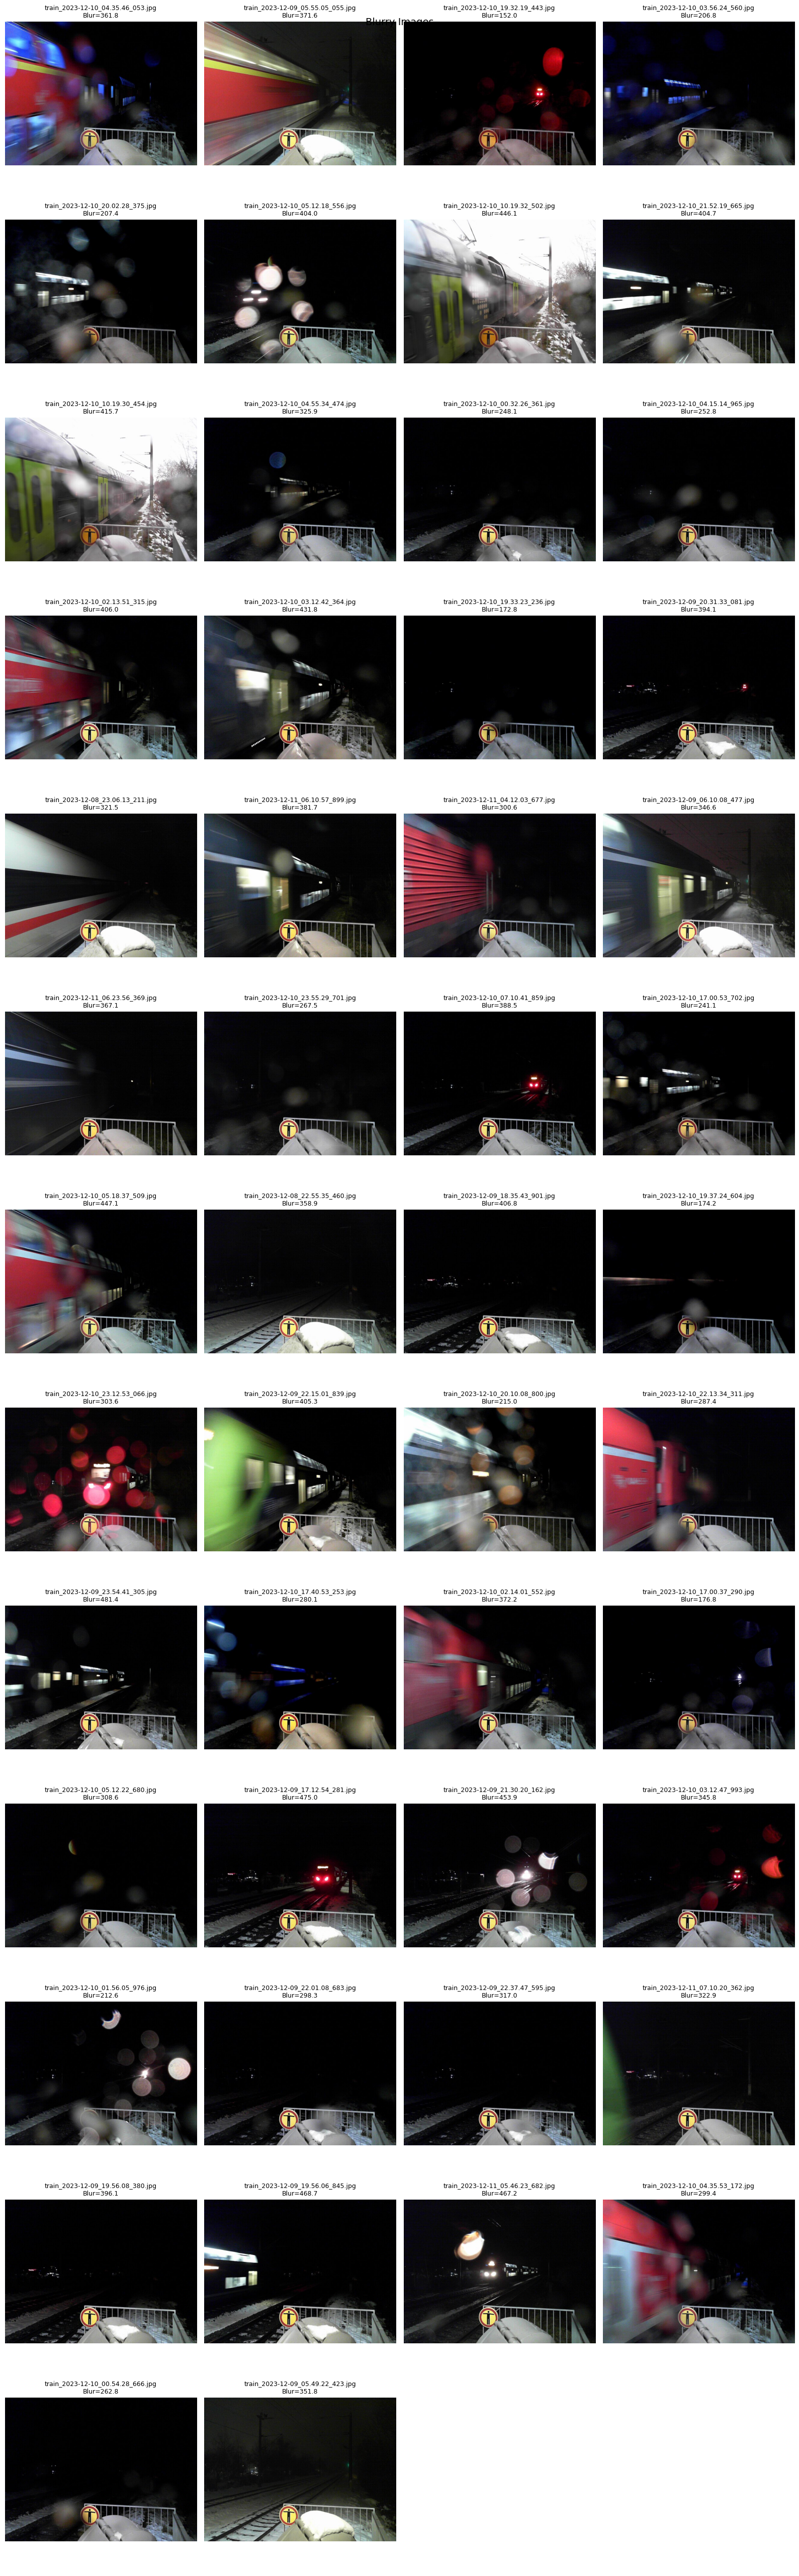

In [10]:
show_images(blurry, title="Blurry Images", max_images=50)


In [1]:
def extract_ground_and_track(img, sky_frac=0.25, track_frac_width=0.4):
    h, w = img.shape[:2]

    # Ground = bottom part
    ground = img[int(h * sky_frac):, :]

    # Central track corridor
    track_w = int(w * track_frac_width)
    x0 = (w - track_w) // 2
    x1 = x0 + track_w
    track = ground[:, x0:x1]

    return ground, track

def snow_whiteness_ratio(bgr, v_thr=170, s_thr=60):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    white_mask = (v >= v_thr) & (s <= s_thr)
    return float(white_mask.mean())

def classify_snow_binary(
    img,
    ground_thr=0.08,   # 8% of ground pixels white
    track_thr=0.05    # 5% of track pixels white
):
    ground, track = extract_ground_and_track(img)

    ground_white = snow_whiteness_ratio(ground)
    track_white = snow_whiteness_ratio(track)

    if ground_white >= ground_thr or track_white >= track_thr:
        return "snow"

    return "no_snow"

from pathlib import Path
from collections import Counter
from tqdm import tqdm
import cv2

def scan_snow_dataset(image_paths):
    labels = []
    for p in tqdm(image_paths):
        img = cv2.imread(str(p))
        if img is None:
            continue
        label = classify_snow_binary(img)
        labels.append(label)
    return Counter(labels)

image_paths = list(Path("/data22/datasets/zollner_dataset/paper_data/images").glob("*.jpg"))
counts = scan_snow_dataset(image_paths)

print(counts)

import random
import matplotlib.pyplot as plt

def show_snow_samples(image_paths, target="snow", k=6):
    selected = []
    for p in image_paths:
        img = cv2.imread(str(p))
        if img is None:
            continue
        if classify_snow_binary(img) == target:
            selected.append(p)

    samples = random.sample(selected, min(k, len(selected)))

    fig, axes = plt.subplots(1, len(samples), figsize=(4*len(samples), 4))
    if len(samples) == 1:
        axes = [axes]

    for ax, p in zip(axes, samples):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(target)
        ax.axis("off")

    plt.show()


100%|██████████| 7000/7000 [00:27<00:00, 256.05it/s]


Counter({'snow': 6253, 'no_snow': 747})


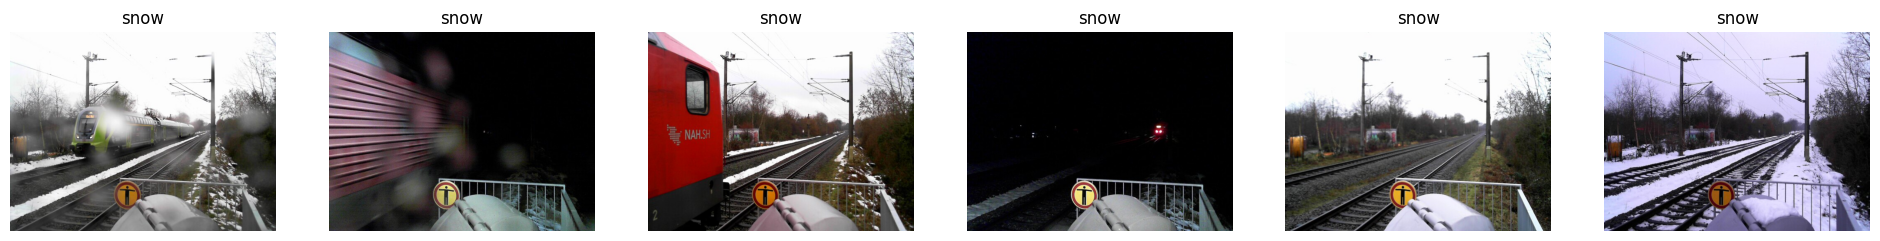

In [2]:
show_snow_samples(image_paths, target="snow", k=6)

### snow and light conditions distribution

In [7]:
import pandas as pd

data = [
    [1, "Light",   "10:59", "16:32", "12-08-23",             "Heavy",             304],
    [1, "Dark", "17:25", "06:31", "12-08-23 / 12-09-23",  "Heavy",             696],
    [2, "Dark", "06:31", "07:35", "12-09-23",             "Heavy",             133],
    [2, "Light",   "07:56", "14:53", "12-09-23",             "Heavy",             867],
    [3, "Light",   "15:11", "16:10", "12-09-23",             "Heavy", 161],
    [3, "Dark", "16:29", "00:15", "12-09-23 / 12-10-23",  "Moderate",          839],
    [4, "Dark", "00:15", "07:10", "12-10-23",             "Moderate",          636],
    [4, "Light",   "07:53", "11:31", "12-10-23",             "Moderate",          364],
    [5, "Light",        "11:31", "16:15", "12-10-23",             "Moderate",          530],
    [5, "Dark",      "16:31", "20:10", "12-10-23",             "Low",               470],
    [6, "Dark",      "20:10", "07:50", "12-10-23 / 12-11-23",  "Low",              1000],
    [7, "Dark",      "07:50", "08:01", "12-11-23",             "Low",                48],
    [7, "Light",        "08:07", "09:31", "12-11-23",             "Low",               132],
    [7, "Light",        "11:13", "13:09", "12-11-23",             "None",              820],
]

columns = [
    "Batch",
    "Day/Night",
    "Start Time",
    "End Time",
    "Date(s)",
    "Snow",
    "Images"
]

df = pd.DataFrame(data, columns=columns)

df


,Batch,Day/Night,Start Time,End Time,Date(s),Snow,Images
0,1,Light,10:59,16:32,12-08-23,Heavy,304
1,1,Dark,17:25,06:31,12-08-23 / 12-09-23,Heavy,696
2,2,Dark,06:31,07:35,12-09-23,Heavy,133
3,2,Light,07:56,14:53,12-09-23,Heavy,867
4,3,Light,15:11,16:10,12-09-23,Heavy,161
5,3,Dark,16:29,00:15,12-09-23 / 12-10-23,Moderate,839
6,4,Dark,00:15,07:10,12-10-23,Moderate,636
7,4,Light,07:53,11:31,12-10-23,Moderate,364
8,5,Light,11:31,16:15,12-10-23,Moderate,530
9,5,Dark,16:31,20:10,12-10-23,Low,470


In [9]:
# Total images
print(df["Images"].sum())

# Images per batch
print(df.groupby("Batch")["Images"].sum())

# Day vs Night split
print(df.groupby("Day/Night")["Images"].sum())

# Snow condition split
print(df.groupby("Snow")["Images"].sum())

7000
Batch
1    1000
2    1000
3    1000
4    1000
5    1000
6    1000
7    1000
Name: Images, dtype: int64
Day/Night
Dark     3822
Light    3178
Name: Images, dtype: int64
Snow
Heavy       2161
Low         1650
Moderate    2369
None         820
Name: Images, dtype: int64
